# Import

In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
import compute_ivt
from compute_ivt import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Domain & Period

In [2]:
#load eastward (u) and northward (v) of IVT
uivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/uivt_monthly_era5_1980-2025_NH_025x025.nc')
vivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vivt_monthly_era5_1980-2025_NH_025x025.nc')

In [3]:
#focus on Middle Asia (MA)
uivt_MA = field_dom(uivt,'MA')
vivt_MA = field_dom(vivt,'MA')

In [4]:
iyear=1980
fyear=2025

# Compute IVT

In [16]:
#Découper le data par paquet de 10
#uivt_MA = uivt_MA.chunk({'valid_time': 10})
#vivt_MA = vivt_MA.chunk({'valid_time': 10})

#Compute IVT
def compute_ivt(uivt, vivt):
    ivt = (uivt['viwve']**2 + vivt['viwvn']**2)**0.5
    return xr.Dataset({'ivt': ivt})

ivt_MA = ivt

#Save as netcdf
#ivt_MA.to_netcdf('/bettik/PROJECTS/pr-regional-climate/bricej/era5/daily/ivt_daily_era5_1980-2025_MA_025x025.nc')

In [17]:
#Open file of IVT
#ivt_MA = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/ivt_monthly_era5_1980-2025_MA_025x025.nc')

In [18]:
ivt_mean = ivt_MA['ivt'].mean(dim='valid_time')

In [19]:
u_mean = uivt_MA['viwve'].mean(dim='valid_time')

In [20]:
v_mean = vivt_MA['viwvn'].mean(dim='valid_time')

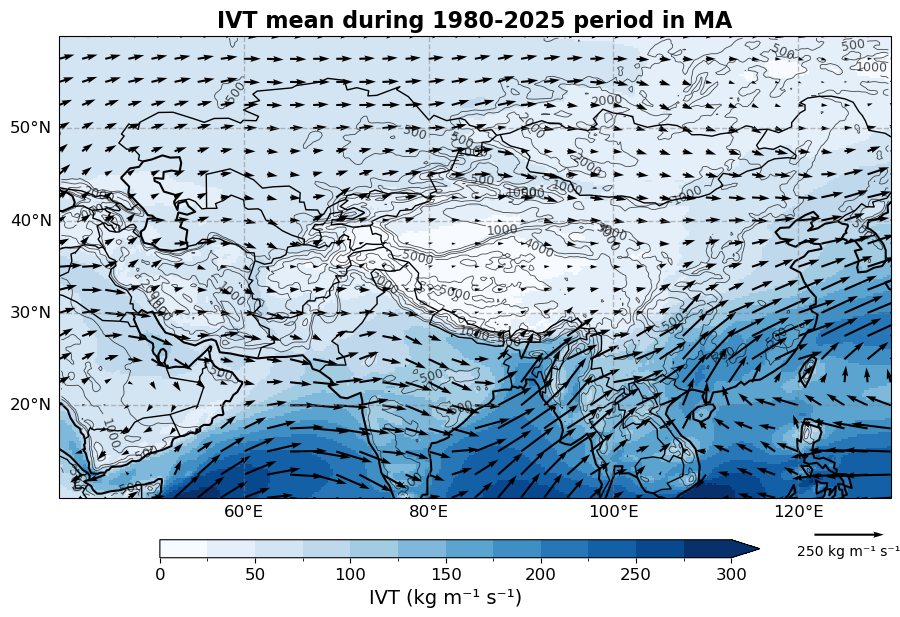

In [21]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#IVT color definition
levels = np.arange(0, ivt_mean.max(), 25)
cmap = plt.get_cmap("Blues", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    ivt_mean['longitude'], ivt_mean['latitude'], ivt_mean,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Map limitations
ax.set_extent([
    float(ivt_mean.longitude.min()),
    float(ivt_mean.longitude.max()),
    float(ivt_mean.latitude.min()),
    float(ivt_mean.latitude.max())
], crs=ccrs.PlateCarree())

#IVT Vectors
step = 10
u_plot = u_mean[::step, ::step]
v_plot = v_mean[::step, ::step]
q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=3000,width=0.0025,headwidth=3
             ,rasterized=True)

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Legends
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("IVT (kg m⁻¹ s⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.95, -0.08,    250,"250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')
ax.set_title(f"IVT mean during {iyear}-{fyear} period in MA", fontsize=16, weight='bold')

#HMA zone
#latS, latN, lonW, lonE, latlim, lonlim = coord_domain('HMA')
#rect = mpatches.Rectangle((lonW, latS), lonE - lonW, latN - latS,linewidth=2, edgecolor='red', facecolor='none',transform=ccrs.PlateCarree())
#ax.add_patch(rect)
#ax.text((lonW + lonE) / 2, latN + 3, "HMA",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
#        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'ivt_mean_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Climatology of IVT

In [22]:
#Group by month + mean
monthly_clim = ivt_MA.groupby('valid_time.month').mean('valid_time')['ivt']
u_monthly_clim = uivt_MA.groupby('valid_time.month').mean('valid_time')['viwve']
v_monthly_clim = vivt_MA.groupby('valid_time.month').mean('valid_time')['viwvn']

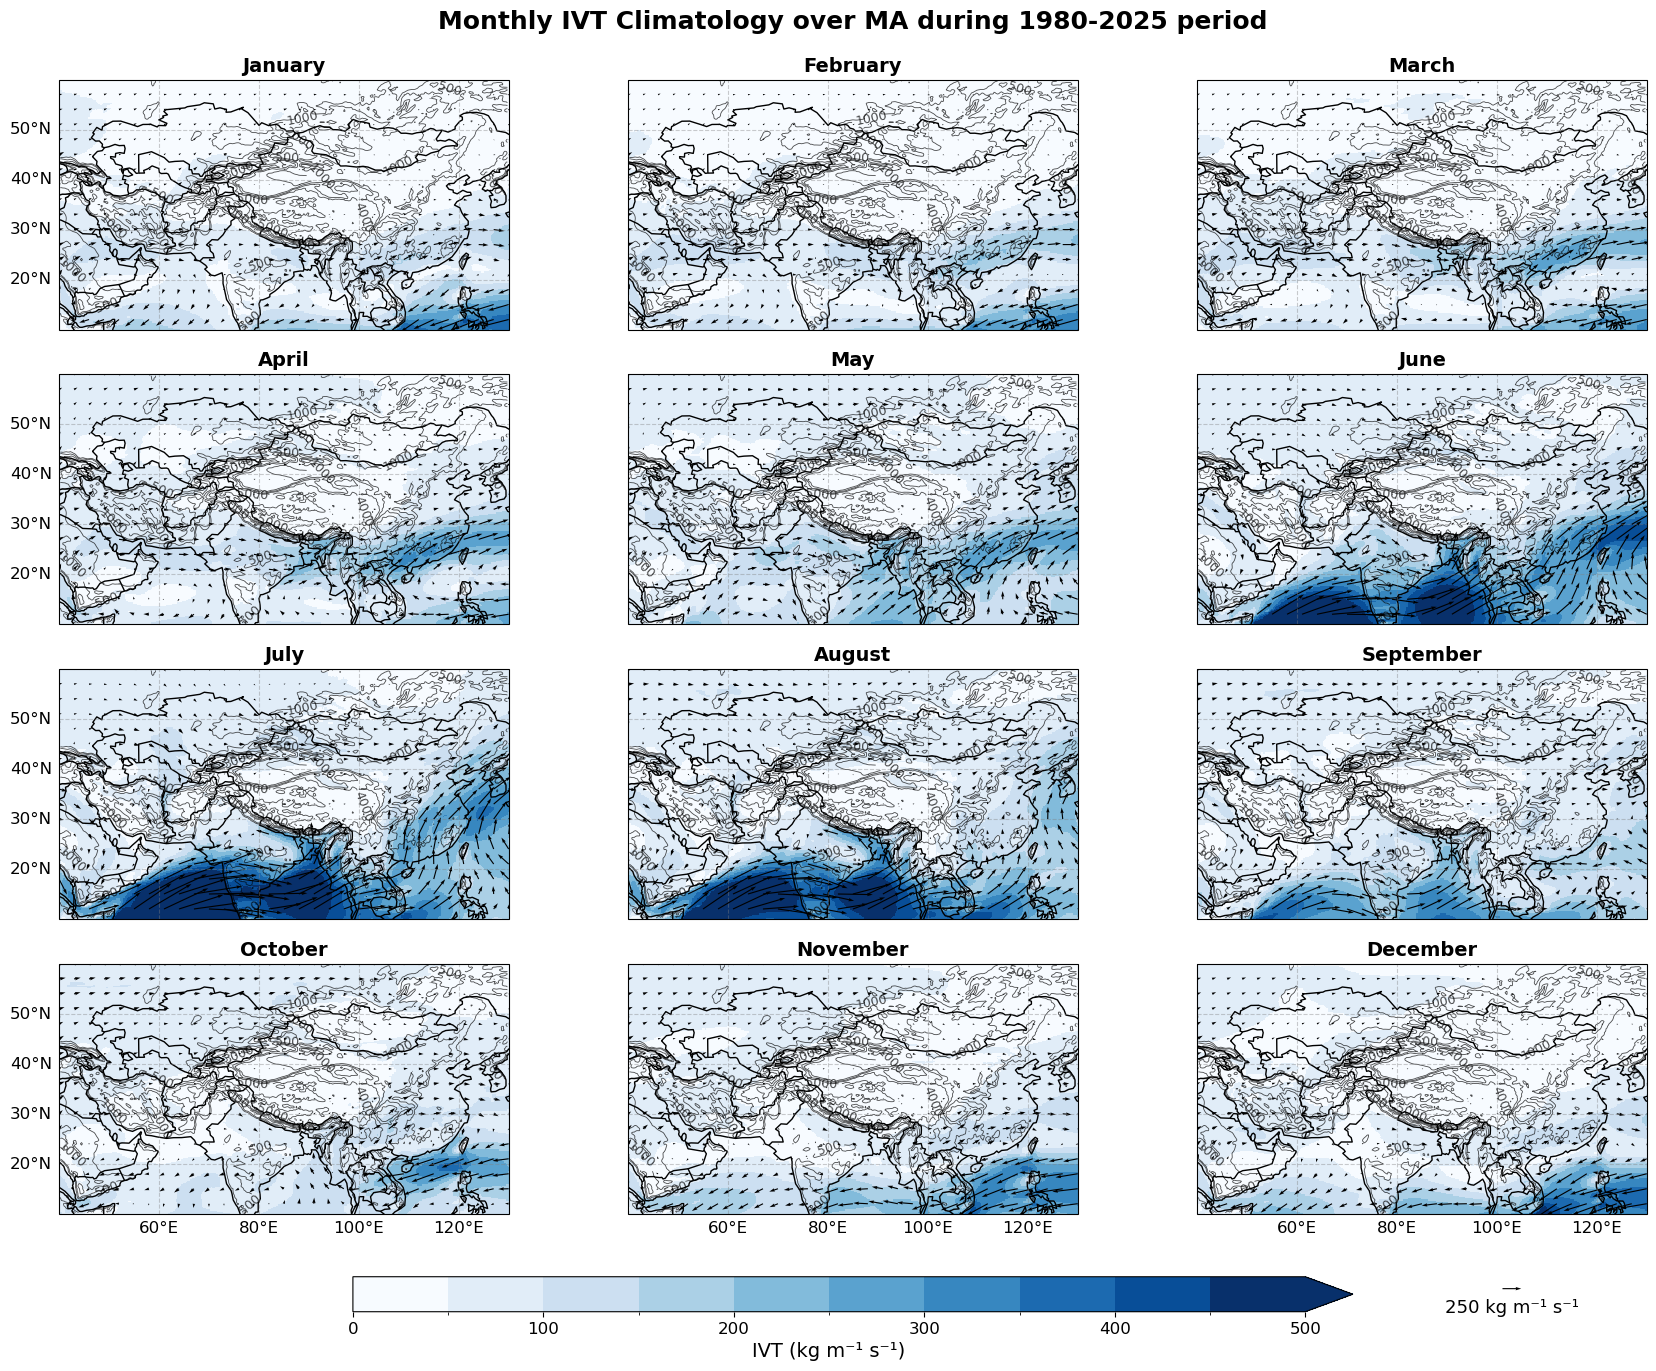

In [23]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
#vmax = float(monthly_clim.max())
levels = np.arange(0, 550, 50)
cmap = plt.get_cmap("Blues")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(4, 3,figsize=(20, 14),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    data_month = monthly_clim.sel(month=i+1)
    im = ax.pcolormesh(data_month.longitude,data_month.latitude,data_month,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(ivt_mean.longitude.min()),
        float(ivt_mean.longitude.max()),
        float(ivt_mean.latitude.min()),
        float(ivt_mean.latitude.max())
    ], crs=ccrs.PlateCarree())

    #IVT Vectors
    step = 12
    u_plot = u_monthly_clim.sel(month=i+1)[::step, ::step]
    v_plot = v_monthly_clim.sel(month=i+1)[::step, ::step]
    q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=6000,width=0.0025,headwidth=3
             ,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                    colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(calendar.month_name[i+1],fontsize=14,weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("IVT (kg m⁻¹ s⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.70, -0.3,250,"250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes', fontproperties={'size': 13})

fig.subplots_adjust(left=0.08,right=0.92,top=0.93,bottom=0.12,wspace=0.05,hspace=0.18)
plt.suptitle(f"Monthly IVT Climatology over MA during {iyear}-{fyear} period",fontsize=18,weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'monthly_ivt_clim_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Climatology of IVT

In [24]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
clim_dict = {}

u_clim_dict = {}
v_clim_dict = {}

#Rename time dimension for 'clim' function
ivt_MA = ivt_MA.rename({'valid_time': 'time'})
uivt_MA = uivt_MA.rename({'valid_time': 'time'})
vivt_MA = vivt_MA.rename({'valid_time': 'time'})


#Climatology for each season
for season in seasons:
    clim_season = clim(ivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    clim_dict[season] = clim_season
    
    u_clim_season = clim(uivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    u_clim_dict[season] = u_clim_season
    
    v_clim_season = clim(vivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    v_clim_dict[season] = v_clim_season

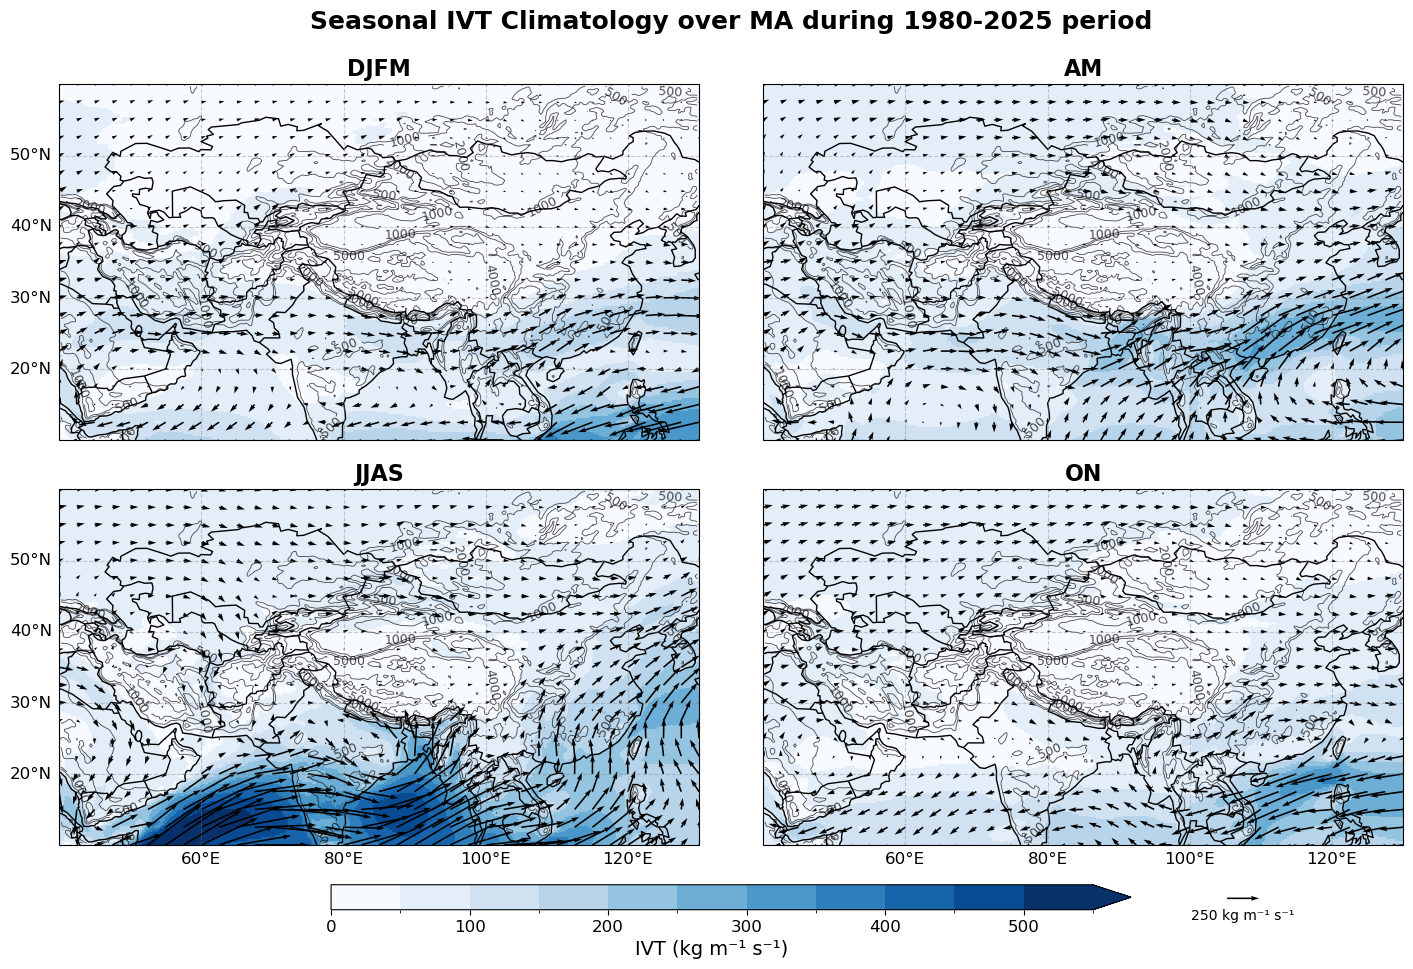

In [25]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
vmin = 0
vmax = max(ds["ivt"].max().item() for ds in clim_dict.values())
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

levels = np.arange(vmin, vmax, 50)
cmap = plt.get_cmap("Blues")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['ivt']

    im = ax.pcolormesh(data_season.longitude,data_season.latitude,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(ivt_mean.longitude.min()),
        float(ivt_mean.longitude.max()),
        float(ivt_mean.latitude.min()),
        float(ivt_mean.latitude.max())
    ], crs=ccrs.PlateCarree())

    #IVT Vectors
    step = 10
    u_plot = u_clim_dict[season]["viwve"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    v_plot = v_clim_dict[season]["viwvn"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    q = ax.quiver(u_plot.longitude,u_plot.latitude,u_plot,v_plot,transform=ccrs.PlateCarree(),scale=5000,width=0.0025,headwidth=3
             ,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("IVT (kg m⁻¹ s⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 250,"250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal IVT Climatology over MA during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'seasonal_ivt_clim_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Annual Trend of IVT

In [36]:
ivt_annual,_ = seasonal_selection(ivt_MA['ivt'], 'JJA', iyear, fyear)
par = trend_vect(ivt_annual.time,ivt_annual,dim='time')
trend = par[0];p = par[3]

uivt_annual,_ = seasonal_selection(uivt_MA['viwve'], 'JJA', iyear, fyear)
u_par = trend_vect(uivt_annual.time,uivt_annual,dim='time')
u_trend = u_par[0];u_p = u_par[3]

vivt_annual,_ = seasonal_selection(vivt_MA['viwvn'], 'JJA', iyear, fyear)
v_par = trend_vect(vivt_annual.time,vivt_annual,dim='time')
v_trend = v_par[0];v_p = v_par[3]

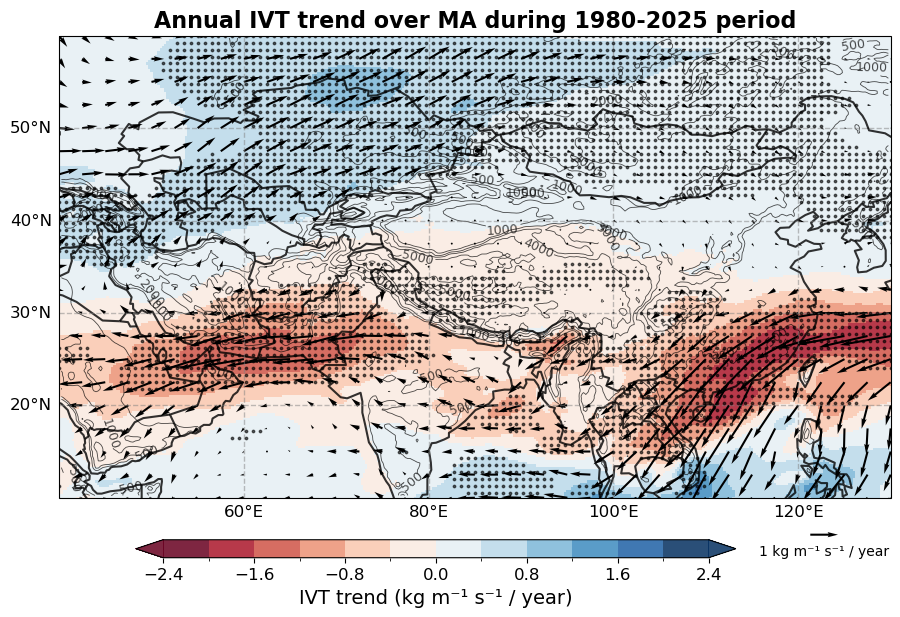

In [128]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

step = 0.4
vmax = 2.4

levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("RdBu", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

pcm = ax.pcolormesh(trend['longitude'],trend['latitude'],trend,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(), alpha=0.85)

#Map limitations
ax.set_extent([
    float(ivt_mean.longitude.min()),
    float(ivt_mean.longitude.max()),
    float(ivt_mean.latitude.min()),
    float(ivt_mean.latitude.max())
], crs=ccrs.PlateCarree())

sig = p < 0.05   # significativity threshold
step = 3  # for stepping the points on the map that appears. 1 point out of 2 on every direction.
#ax.contourf(trend['longitude'],trend['latitude'],sig,levels=[0.5, 1],hatches=['///'],colors='none',transform=ccrs.PlateCarree())
lon_sig, lat_sig = trend['longitude'].values, trend['latitude'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
          color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.6)

#IVT Vectors
step = 10
u_plot = u_trend[::step, ::step]
v_plot = v_trend[::step, ::step]
q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=30,width=0.0025,headwidth=2.5
             ,rasterized=True)

ax.coastlines(linewidth=1.5, alpha = 0.8)
ax.add_feature(cfeature.BORDERS, linewidth=1.5, alpha = 0.8)

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.23, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("IVT trend (kg m⁻¹ s⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.92, -0.08, 1,"1 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')

ax.set_title(f"Annual IVT trend over MA during {iyear}-{fyear} period", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'ivt_trend_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

In [ ]:
###################### ivt trend =! sqrt(utrend^2 + vtrend^2) ###################################

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

step = 0.2
vmax = 1.2
#vmax = np.ceil(np.abs(trend).max().item())

#levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("RdBu_r", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

pcm = ax.pcolormesh(trend['longitude'],trend['latitude'],trend,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(), alpha=0.85)

#Map limitations
ax.set_extent([
    float(ivt_mean.longitude.min()),
    float(ivt_mean.longitude.max()),
    float(ivt_mean.latitude.min()),
    float(ivt_mean.latitude.max())
], crs=ccrs.PlateCarree())

sig = p < 0.05   # significativity threshold
step = 3   # for stepping the points on the map that appears. 1 point out of 2 on every direction.
##ax.contourf(trend['longitude'],trend['latitude'],sig,levels=[0.5, 1],hatches=['///'],colors='none',transform=ccrs.PlateCarree())
lon_sig, lat_sig = trend['longitude'].values, trend['latitude'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.6)

#IVT Vectors
step = 10
u_plot = u_trend[::step, ::step]
v_plot = v_trend[::step, ::step]
trend_plot = trend[::step, ::step]
vect_norm = np.sqrt(u_plot**2 + v_plot**2)
scale_factor = np.where(vect_norm==0, 0, trend_plot / vect_norm)
u_scaled = u_plot * scale_factor
v_scaled = v_plot * scale_factor
q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_scaled, v_scaled,transform=ccrs.PlateCarree(),
              scale=20,width=0.0025,headwidth=2.5,rasterized=True)

ax.coastlines(linewidth=1.5, alpha = 0.8)
ax.add_feature(cfeature.BORDERS, linewidth=1.5, alpha = 0.8)

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.23, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("IVT trend (kg m⁻¹ s⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.92, -0.08, 1,"1 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')

ax.set_title(f"Annual IVT trend over MA during {iyear}-{fyear} period", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'ivt_trend_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Trends of IVT

In [ ]:
seasons = [1,2,3,4,5,6,7,8,9,10,11,12]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Rename time dimension for 'clim' function
#ivt_MA = ivt_MA.rename({'valid_time': 'time'})

#Climatology for each season
for season in seasons:
    ivt_season,_ = monthly_selection(ivt_MA['ivt'], season, start_year, end_year)
    par = trend_vect(ivt_season.time.dt.year,ivt_season,dim='time')
    trend_season = par[0];p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = monthly_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time.dt.year,uivt_season,dim='time')
    u_trend_season = u_par[0];u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = monthly_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time.dt.year,vivt_season,dim='time')
    v_trend_season = v_par[0];v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

In [ ]:
seasons_str = ["January", "February", "March", "April",
                "May", "June", "July", "August",
                "September", "October", "November", "December"]
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

step = 0.8
vmax = 4
#vmax = max(np.ceil(np.abs(ds).max().item()) for ds in trend_dict.values())
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("RdBu", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(4, 3, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(ivt_mean.longitude.min()),
        float(ivt_mean.longitude.max()),
        float(ivt_mean.latitude.min()),
        float(ivt_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p < 0.05   
    step = 5
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=3.5, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha = 0.6)

    step = 12
    trend_plot = trend[::step, ::step]
    vect_norm = np.sqrt(u_plot**2 + v_plot**2)
    scale_factor = np.where(vect_norm==0, 0, trend_plot / vect_norm)
    u_scaled = u_plot * scale_factor
    v_scaled = v_plot * scale_factor
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_scaled, v_scaled,transform=ccrs.PlateCarree(),
                  scale=20,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(seasons_str[i], fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("IVT trend (kg m⁻¹ s⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.70, -0.3, 4,"4 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Monthly IVT trend over MA during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'monthly_ivt_trend_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Trends of IVT

In [ ]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Rename time dimension for 'clim' function
#ivt_MA = ivt_MA.rename({'valid_time': 'time'})

#Climatology for each season
for season in seasons:
    ivt_season,_ = seasonal_selection(ivt_MA['ivt'], season, start_year, end_year)
    par = trend_vect(ivt_season.time,ivt_season,dim='time')
    trend_season = par[0];p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = seasonal_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time,uivt_season,dim='time')
    u_trend_season = u_par[0];u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = seasonal_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time,vivt_season,dim='time')
    v_trend_season = v_par[0];v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

In [ ]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
step = 0.5
vmax = 2.5
#vmax = max(np.ceil(np.abs(ds).max().item()) for ds in trend_dict.values())
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(ivt_mean.longitude.min()),
        float(ivt_mean.longitude.max()),
        float(ivt_mean.latitude.min()),
        float(ivt_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p < 0.05   
    step = 3
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2.5, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.5)

    step = 10
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    trend_plot = trend_dict[season][::step, ::step]
    vect_norm = np.sqrt(u_plot**2 + v_plot**2)
    scale_factor = np.where(vect_norm==0, 0, trend_plot / vect_norm)
    u_scaled = u_plot * scale_factor
    v_scaled = v_plot * scale_factor
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_scaled, v_scaled,transform=ccrs.PlateCarree(),
                  scale=30,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("IVT trend (kg m⁻¹ s⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 2,"2 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal IVT trend over MA during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_IVT_era5/"
#plotname=f'monthly_ivt_trend_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()